# Characterize a backend

This notebook shows how to easily run a set of characterization experiments to get an updated backend reflecting real-time device properties (readout error, 1Q errors, 2Q errors, T1, T2). The main idea is to return a backend that shows real-time device properties, as opposed to relying on the properties reported on Qiskit.

In [1]:
import sys
import logging

from qiskit_ibm_runtime import QiskitRuntimeService, Batch
from qiskit_device_benchmarking.utilities.characterization_utils import BackendCharacterization, plot_characterization_comparison

## Select backend

In [ ]:
service = QiskitRuntimeService()
device = "ibm_fez"
backend = service.backend(device)

## Enable logging to see progress

In [3]:
logger = logging.getLogger("qiskit_device_benchmarking")
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(stream=sys.stdout))

## Specify and run characterization experiments

Choose either of the options shown below to run the characterization experiments and update the backend object. This can be done either outside or inside of a Session or Batch. One can choose to run any experiment in the following subset: 
- readout: SPAM (state preparation and measurement) experiment
- rb_1q: Isolated 1Q RB
- rb_2q: Simultaneous 2Q RB from a layer fidelity experiment
- t1: T1 experiment
- t2: T2 Hahn experiment

_Usage estimate: 70 seconds on a Heron r2 processor (NOTE: This is an estimate only. Your runtime might vary.)_

<div class="alert alert-block alert-info">
<b>Note:</b> The following two cells do not return until all jobs and post-processing are done.
</div>

In [4]:
# Initialize the class used to run the experiments
characterizer = BackendCharacterization(backend)

# Run characterization experiments and get an updated backend
experiments = ['readout', 'rb_1q', 'rb_2q', 't1', 't2']
backend_updated = characterizer.run_and_update(experiments=experiments)

Building readout experiments
Building 1Q RB experiments
Building 2Q RB experiments
Building T1 experiments
Building T2 experiments
Layered two-qubit RB submitted: ['d81le9noha1c73bki7og', 'd81lekftjchs73bn2fn0', 'd81lf86gbeec73ako4p0', 'd81lfimgbeec73ako540']
Readout job submitted: d81lfio0bvlc73d1930g
T1 experiment submitted: ['d81lfjfoha1c73bki9i0']
T2 (Hahn) experiment submitted: ['d81lfk00bvlc73d19320']
Single-qubit RB submitted: ['d81lgt80bvlc73d194m0', 'd81lh4ntjchs73bn2ir0']
Updating readout error
Updating single-qubit X error
Updating single-qubit SX error
Updating two-qubit error
Updating T1
Updating T2


In [ ]:
# Initialize the class used to run the experiments
characterizer = BackendCharacterization(backend)

# Run characterization experiments inside a Batch.
# You might see a warning about passing a backend inside a session context manager, which can be safely ignored.
experiments = ['readout', 'rb_1q', 'rb_2q', 't1', 't2']
with Batch(backend=backend):
    backend_updated = characterizer.run_and_update(experiments=experiments)

base_primitive.get_mode_service_backend:WARNING:2026-05-12 13:29:18,631: A backend was passed in as the mode but a session context manager is open so this job will run inside this session/batch instead of in job mode.


Building readout experiments
Building 1Q RB experiments
Building 2Q RB experiments
Building T1 experiments
Building T2 experiments
Layered two-qubit RB submitted: ['d81m7dnoha1c73bkj6s0', 'd81m7iegbeec73akp3fg', 'd81m85g0bvlc73d1a130', 'd81m8a7oha1c73bkj7s0']
Readout job submitted: d81m8vegbeec73akp570
T1 experiment submitted: ['d81m8vugbeec73akp580']
T2 (Hahn) experiment submitted: ['d81m90ntjchs73bn3h0g']
Single-qubit RB submitted: ['d81ma4noha1c73bkj9u0', 'd81mad00bvlc73d1a3n0']
Updating readout error
Updating single-qubit X error
Updating single-qubit SX error
Updating two-qubit error
Updating T1
Updating T2


## Run the workflow in multiple steps

The examples above showed you how to run all experiments and get an updated `Backend` in a single call. You can, however, run the workflow in separate steps. Doing so allows you to, for example, do the analysis and update asynchronously. 

### 1. Run all the benchmarking experiments 

In [4]:
# Initialize the class used to run the experiments
characterizer = BackendCharacterization(backend)

# Run characterization experiments and get an updated backend
experiments = ['readout', 'rb_1q', 'rb_2q', 't1', 't2']
with Batch(backend=backend):
    jobs = characterizer.run_experiments(experiments=experiments)

base_primitive.get_mode_service_backend:WARNING:2026-05-14 10:47:34,443: A backend was passed in as the mode but a session context manager is open so this job will run inside this session/batch instead of in job mode.


Building readout experiments
Building 1Q RB experiments
Building 2Q RB experiments
Building T1 experiments
Building T2 experiments
Layered two-qubit RB submitted: ['d82u1omgbeec73am9ie0', 'd82u1uftjchs73bohm00', 'd82u2jmgbeec73am9jbg', 'd82u2po0bvlc73d2pdjg']
Readout job submitted: d82u2q6gbeec73am9ji0
T1 experiment submitted: ['d82u2qvtjchs73bohmrg']
T2 (Hahn) experiment submitted: ['d82u2rmgbeec73am9jk0']
Single-qubit RB submitted: ['d82u3tvoha1c73bm2450', 'd82u46ftjchs73boho90']


In [ ]:
# Print all the job IDs for debugging purposes
jobs

{'readout': [<RuntimeJobV2('d7v4jmtpa59c73b5eppg', 'sampler')>],
 'rb_1q': [<RuntimeJobV2('d7v4kqvmrars73d7o72g', 'sampler')>,
  <RuntimeJobV2('d7v4l3dpa59c73b5erdg', 'sampler')>],
 'rb_2q': [<RuntimeJobV2('d7v4ltback5s73bevhn0', 'sampler')>,
  <RuntimeJobV2('d7v4m3nmrars73d7o8hg', 'sampler')>,
  <RuntimeJobV2('d7v4mstpa59c73b5et80', 'sampler')>,
  <RuntimeJobV2('d7v4n4fmrars73d7o9qg', 'sampler')>],
 't1': [<RuntimeJobV2('d7v4n53ack5s73bevj3g', 'sampler')>],
 't2': [<RuntimeJobV2('d7v4n5rack5s73bevj4g', 'sampler')>]}

### 2. Analyze job results

In [5]:
error_maps = characterizer.analyze_results()

In [6]:
print(f"The following error maps are available: {list(error_maps.keys())}")
print(f"For example, readout error for qubit 0 is {error_maps['readout_error'][0]}")

The following error maps are available: ['readout_error', 'oneq_error_x', 'oneq_error_sx', 'lf_error_map', 't1_map', 't2_map']
For example, readout error for qubit 0 is 0.013950000000000018


### 3. Update backend properties

In [7]:
backend_updated = characterizer.update_backend()

Updating readout error
Updating single-qubit X error
Updating single-qubit SX error
Updating two-qubit error
Updating T1
Updating T2


## Plot characterization results

Finally, one can optionally plot a comparison between the reported backend properties on Qiskit and the measured real-time properties.

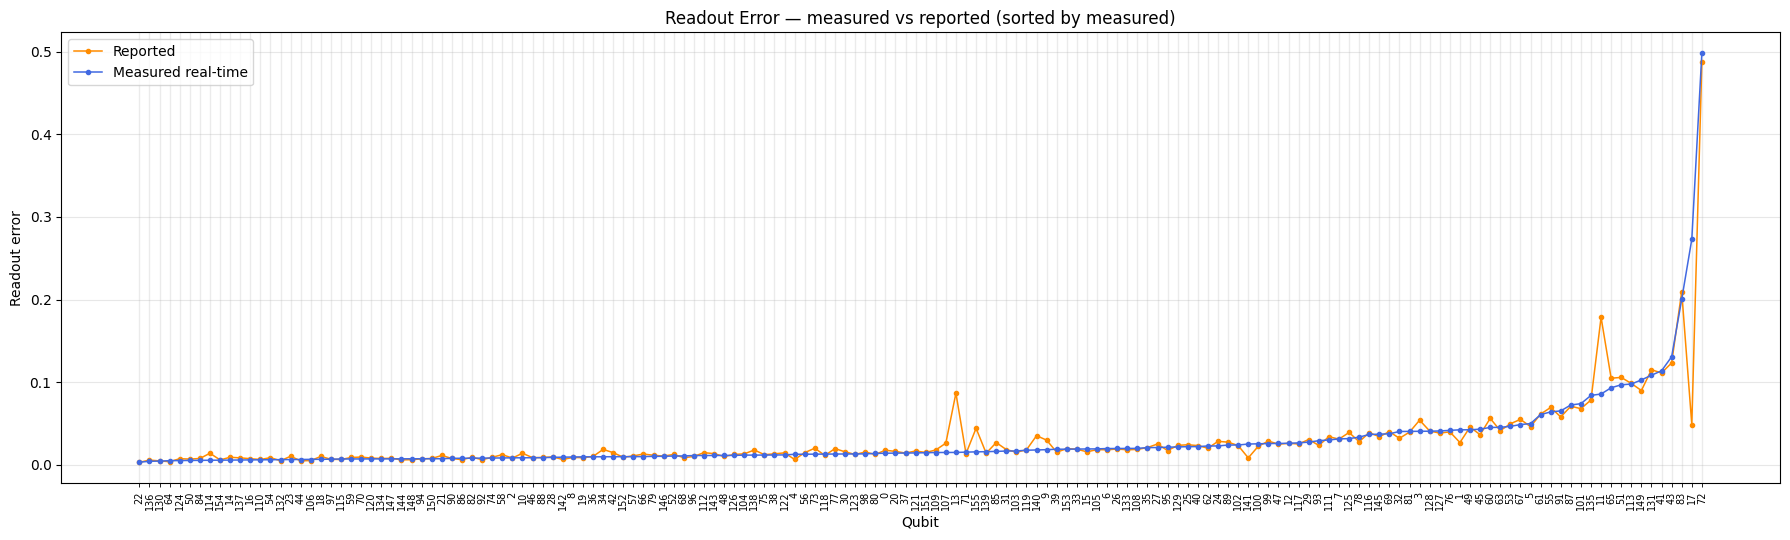

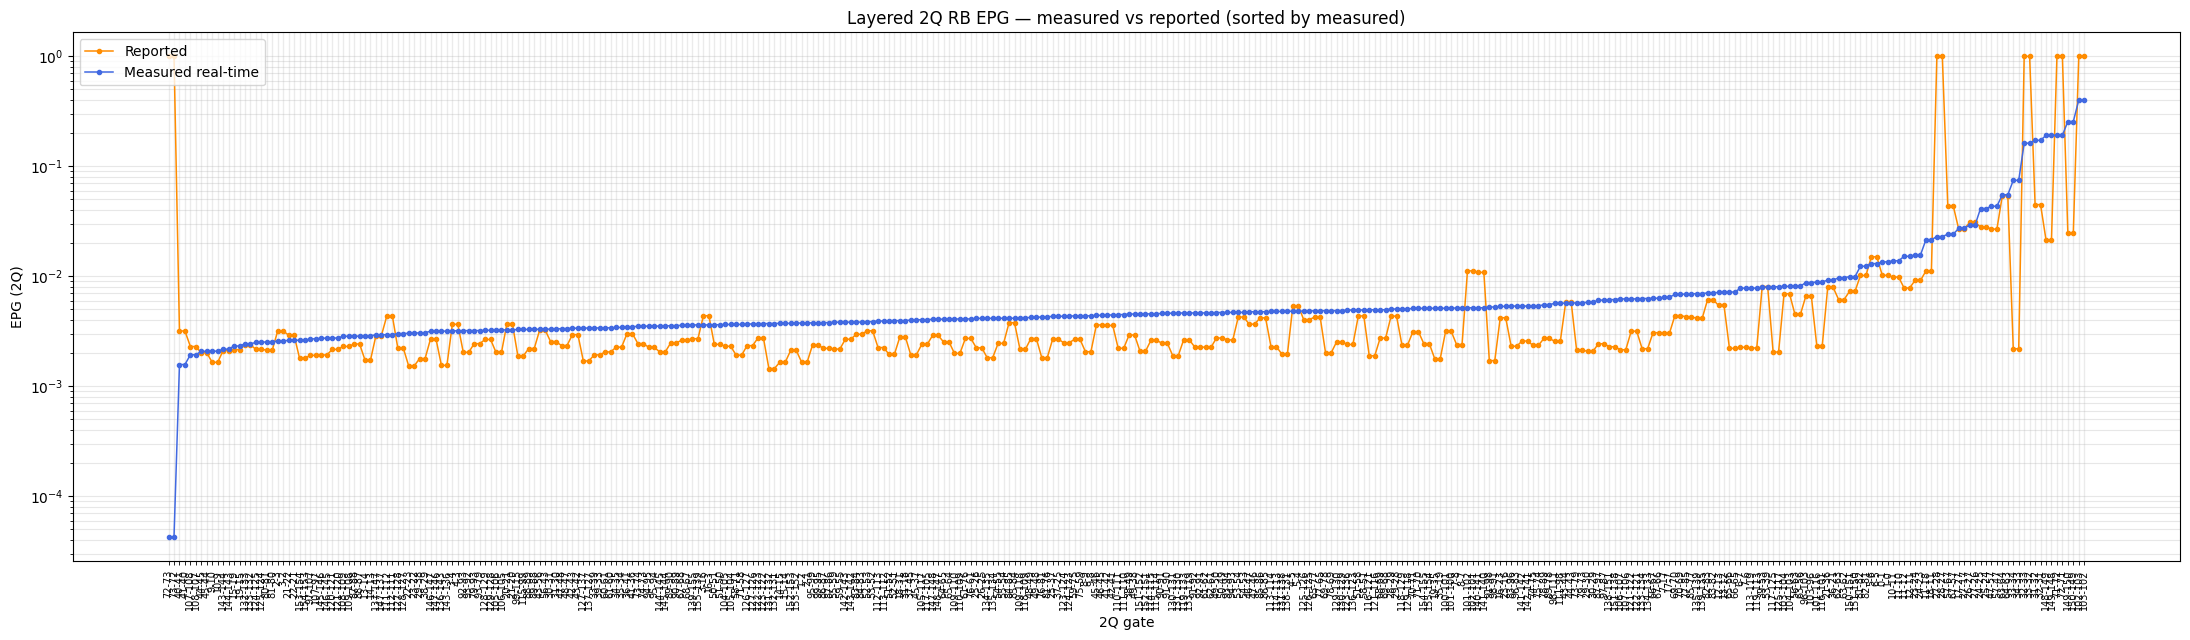

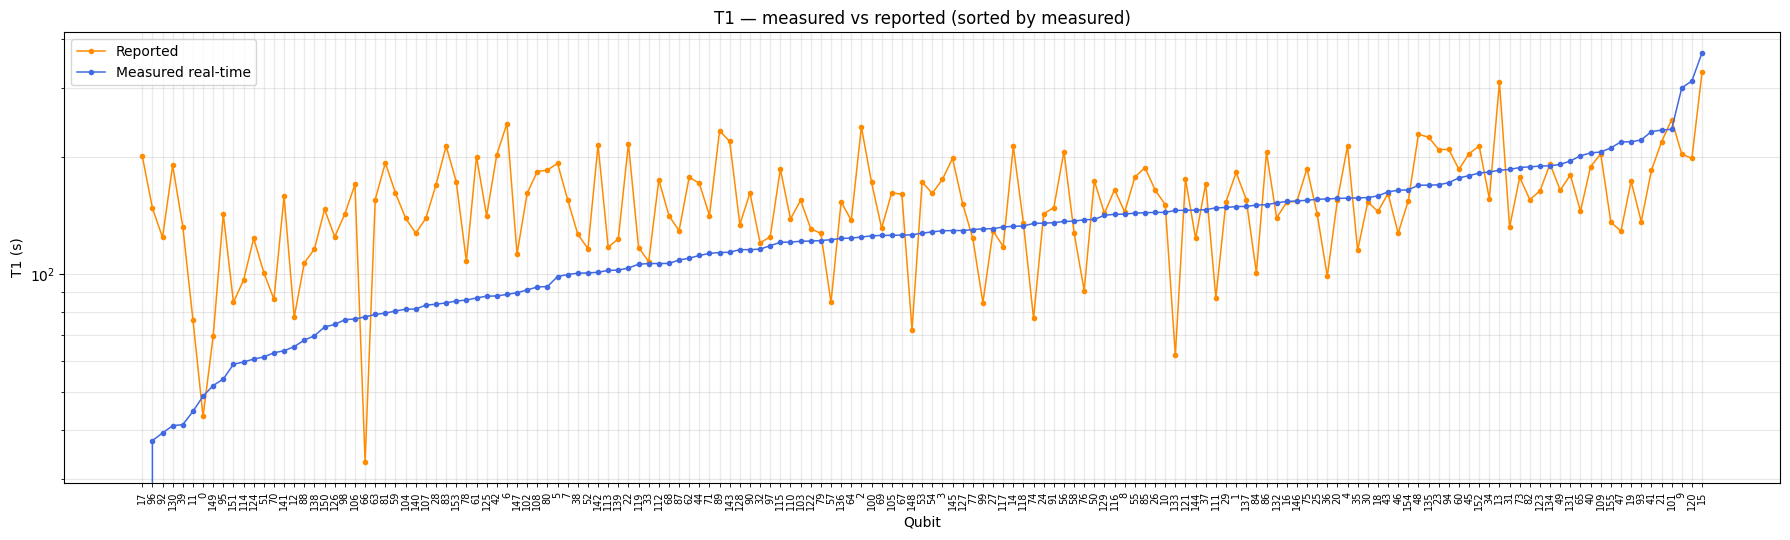

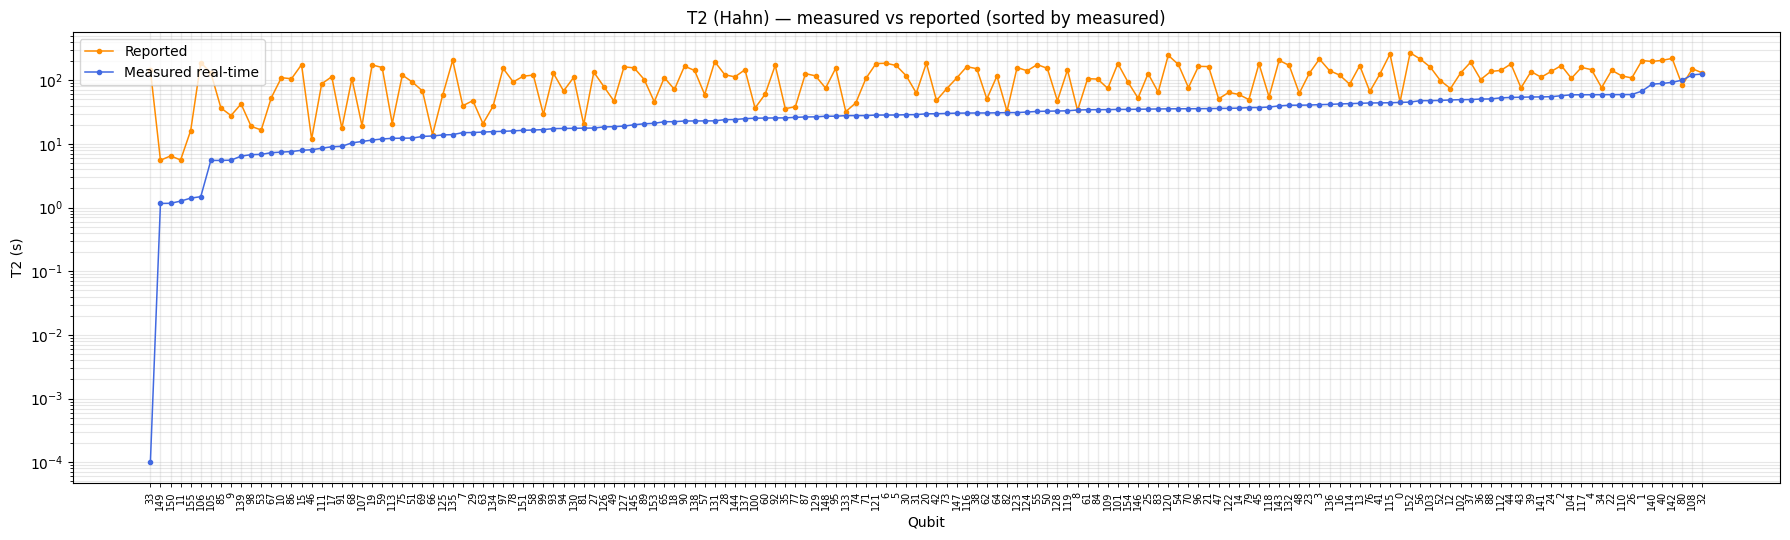

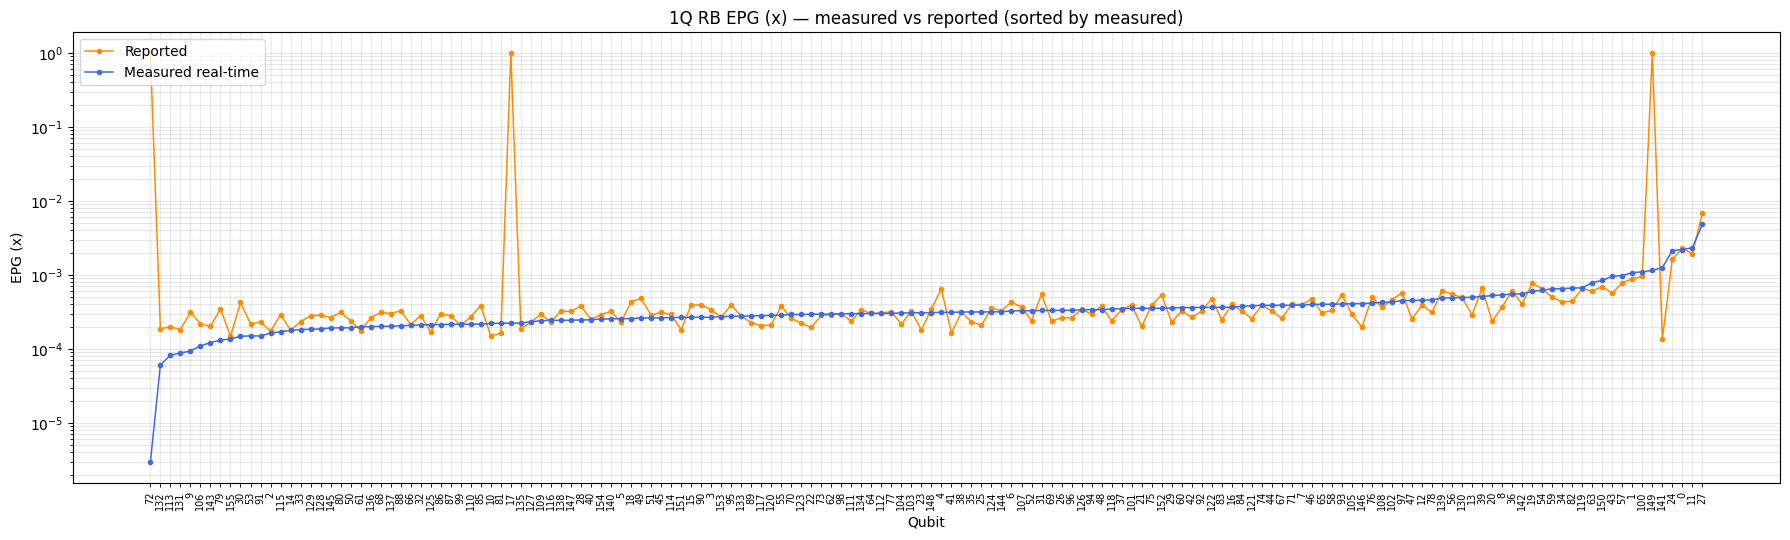

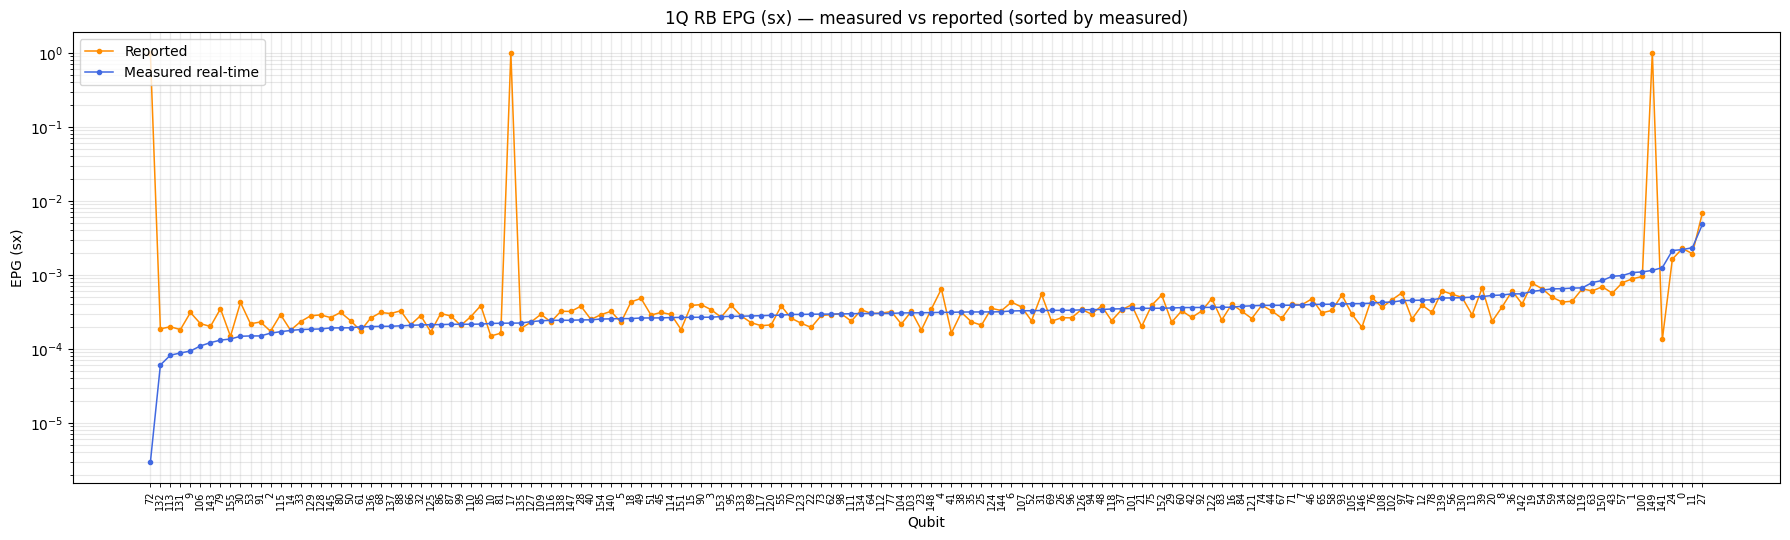

In [8]:
plot_characterization_comparison(
    old_props=backend.properties().to_dict(),
    new_props=backend_updated.properties().to_dict(),
    plots = ['readout', 'rb_1q', 'rb_2q', 't1', 't2'],
)

In [6]:
import datetime
from IPython.display import HTML, display


def qiskit_copyright(line="", cell=None):
    """IBM copyright"""
    now = datetime.datetime.now()

    html = "<div style='width: 100%; background-color:#d5d9e0;"
    html += "padding-left: 10px; padding-bottom: 10px; padding-right: 10px; padding-top: 5px'>"
    html += "<p>&copy; Copyright IBM 2017, %s.</p>" % now.year
    html += (
        "<p>This code is licensed under the Apache License, Version 2.0. You may<br>"
    )
    html += "obtain a copy of this license in the LICENSE.txt file in the root directory<br> "
    html += "of this source tree or at http://www.apache.org/licenses/LICENSE-2.0."

    html += "<p>Any modifications or derivative works of this code must retain this<br>"
    html += "copyright notice, and modified files need to carry a notice indicating<br>"
    html += "that they have been altered from the originals.</p>"
    html += "</div>"
    return display(HTML(html))


qiskit_copyright()

